# Global Forest Canopy Height, 2019

### Importar bibliotecas

In [ ]:
#!pip install geopandas
#!pip install rasterio
#!pip install rasterstats
#!pip install contextily


In [ ]:

import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
import matplotlib.pyplot as plt
import contextily as ctx
from rasterio.mask import mask
import matplotlib.pyplot as plt
from rasterio.plot import show

  Using cached contextily-1.6.2-py3-none-any.whl.metadata (2.9 kB)
  Using cached geopy-2.4.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached mercantile-1.2.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached geographiclib-2.0-py3-none-any.whl.metadata (1.4 kB)
Using cached contextily-1.6.2-py3-none-any.whl (17 kB)
Using cached geopy-2.4.1-py3-none-any.whl (125 kB)
Using cached mercantile-1.2.1-py3-none-any.whl (14 kB)
Using cached geographiclib-2.0-py3-none-any.whl (40 kB)


In [ ]:
# Cargar shapefile (Quintana Roo)
shapefile_path = "../insumos/QuintanaRoo_Entidad_wgs84.gpkg"
gdf = gpd.read_file(shapefile_path)

# Cargar datos del GFCH
raster_path = "../insumos/Forest_height_2019_NAM.tif"

with rasterio.open(raster_path) as src:
    raster_crs = src.crs
    
    # Reproyectar shapefile al CRS del raster
    if gdf.crs != raster_crs:
        gdf = gdf.to_crs(raster_crs)
    
    # generar una mascara para el recorte 
    geometries = gdf.geometry.values
    
    # Aplicar el recorte
    out_image, out_transform = mask(src, geometries, crop=True)
    out_meta = src.meta.copy()

# Actualizar metadata para el nuevo tamaño del raster recortado
out_meta.update({
    "driver": "GTiff",
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# Guardar el nuevo raster en la carpeta de productos
output_path = "../productos/Forest_height_QROO.tif"
with rasterio.open(output_path, "w", **out_meta) as dest:
    dest.write(out_image)

print("Recorte completado y guardado en:", output_path)


Recorte completado y guardado en: ../productos/Forest_height_QROO.tif


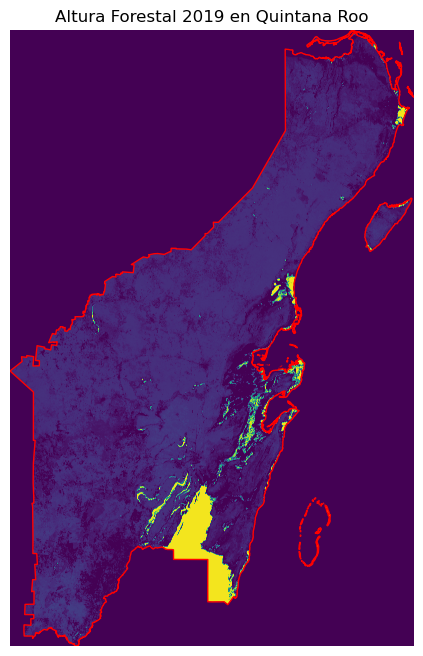

In [ ]:
# Ruta al raster recortado desde la carpeta de productos
recorte_path = "../productos/Forest_height_QROO.tif"
#Visualización
with rasterio.open(recorte_path) as src:
    fig, ax = plt.subplots(figsize=(10, 8))
    show(src, ax=ax, cmap='viridis')
    gdf.boundary.plot(ax=ax, color='red', linewidth=1)  
    ax.set_title("Altura Forestal 2019 en Quintana Roo")
    plt.axis('off')
    plt.show()


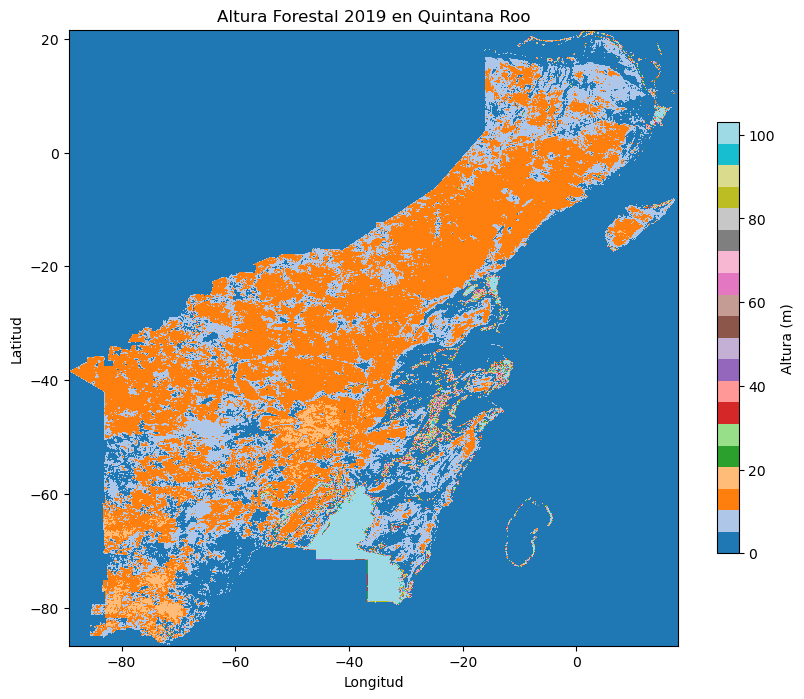

In [ ]:



with rasterio.open(recorte_path) as src:
    data = src.read(1)
    
    # Crear la figura
    fig, ax = plt.subplots(figsize=(10, 8))

    # Mostrar el raster y guardar el objeto de la imagen para la colorbar
    img = ax.imshow(data, cmap='tab20', extent=src.bounds, origin='upper')

  
    # Títulos y etiquetas
    ax.set_title("Altura Forestal 2019 en Quintana Roo")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")

    # Añadir la barra de color
    cbar = plt.colorbar(img, ax=ax, shrink=0.7)
    cbar.set_label("Altura (m)")

    plt.show()
